In [1]:
import os
import pandas as pd
import numpy as np
import sys
from pathlib import Path

project_root = Path.cwd().resolve().parent
print(project_root)
sys.path.insert(0, str(project_root))
from llm_localizer.model_utils import model_name_map, get_num_blocks, get_hidden_dim
import matplotlib.pyplot as plt
import seaborn as sns



/home/tu/tu_tu/tu_nnspt01/tomXprag


### Plotting localizations with original AlKhamissi materials

In [6]:
CACHE_DIR = "../cache_baseline"

In [28]:
file_list = os.listdir(f"{CACHE_DIR}")
print("all files ", len(file_list))
selectivities_data_tom = {}
selectivities_data_lang = {}
for path in file_list:
    print("path ", path)
    if "pvalues" in path:
        continue
    if path == "plots":
        continue
    model_name = path.split("_network=")[0]
    network = "theory-of-mind" if "theory-of-mind" in path else "language"
    is_chat = path.split("_")[-1].replace(".npy", "")
    print("plotting results for model:", model_name, network, is_chat)
    plot_data = {"selectivity": [], "layer_num": [], "model_name": []}  

    model_name = os.path.basename(model_name)
    num_layers = get_num_blocks(model_name)
    hidden_dim = get_hidden_dim(model_name)

    print(f"Model: {model_name}")

    pooling = "mean" if network != "language" else "last-token"
    model_loc_path = path
    # model_loc_path = f"{model_name}_network={network}_pooling={pooling}_range=100-100_perc={percentage}_nunits=None_pretrained=True.npy"

    cache_dir = "../cache_baseline" #"../cache"
    lang_mask_path = f"{cache_dir}/{model_loc_path}"
    if not os.path.exists(lang_mask_path):
        print(f"Path does not exist: {lang_mask_path}")
        continue

    lang_mask = np.load(lang_mask_path)

    for i in range(num_layers):
        layer_mask = lang_mask[i]

        value = 0 if len(layer_mask) == 0 else (layer_mask.sum() / hidden_dim) * 100
        plot_data["selectivity"].append(value)

        plot_data["layer_num"].append((i+1))
        plot_data["model_name"].append(model_name_map[model_name])

    plot_data["relative_layer_num"] = [ln / num_layers for ln in plot_data["layer_num"]]
    if network == "theory-of-mind":
        selectivities_data_tom[model_name] = plot_data
    else:
        selectivities_data_lang[model_name] = plot_data

    df = pd.DataFrame(plot_data)

all files  165
path  Falcon3-10B-Instruct_network=theory-of-mind_pooling=last-token_pretrained=True_suite=tom_percentage=1_p=0.05_mask=theory-of-mind-conjunctive_fdr.npy
plotting results for model: Falcon3-10B-Instruct theory-of-mind fdr
Model: Falcon3-10B-Instruct
Path does not exist: ../cache_baseline/Falcon3-10B-Instruct_network=theory-of-mind_pooling=last-token_pretrained=True_suite=tom_percentage=1_p=0.05_mask=theory-of-mind-conjunctive_fdr.npy
path  Llama-3.1-8B-Instruct_network=theory-of-mind_pooling=last-token_pretrained=True_suite=tom_percentage=1_p=0.05_mask=random-conjunctive_fdr.npy
plotting results for model: Llama-3.1-8B-Instruct theory-of-mind fdr
Model: Llama-3.1-8B-Instruct
Path does not exist: ../cache_baseline/Llama-3.1-8B-Instruct_network=theory-of-mind_pooling=last-token_pretrained=True_suite=tom_percentage=1_p=0.05_mask=random-conjunctive_fdr.npy
path  Qwen2.5-32B-Instruct_network=theory-of-mind_pooling=last-token_pretrained=True_suite=tom_percentage=1_p=0.05_mask

KeyError: '.ipynb_checkpoints'

In [28]:
len(list(set(selectivities_data_tom.keys())))

33

In [29]:
blues = sns.color_palette("Blues")
reds = sns.color_palette("Reds")
greens = sns.color_palette("Greens")
oranges = sns.color_palette("Oranges")
purples = sns.color_palette("Purples")
yellows = sns.color_palette("YlOrBr")
light_blues = sns.color_palette("light:b")

MODEL_PAL = {
    "OLMo-7B-0724-hf": oranges[0],
    "OLMo-7B-0724-Instruct-hf": oranges[0],
    
    "Llama-3.2-3B": greens[1],
    "Llama-2-7b-hf": greens[2],
    "Llama-2-7b-chat-hf": greens[2],
    "Llama-3.1-8B": greens[3],
    "Llama-3.1-8B-Instruct": greens[3],
    "Llama-2-13b-hf": greens[4],
    "Llama-2-13b-chat-hf": greens[4],
    "Llama-3.1-70B": greens[5],
    "Llama-3.3-70B-Instruct": greens[5],
    "Llama-2-70b-hf": greens[5],
    "Llama-2-70b-chat-hf": greens[5],

    "pythia-6.9b-deduped": reds[3],
    "pythia-12b-deduped": reds[4],

    "Falcon3-7B-Base": yellows[2],
    "Falcon3-7B-Instruct": yellows[2],
    "Falcon3-10B-Base": yellows[3],
    "Falcon3-10B-Instruct": yellows[3],

    "gemma-1.1-7b-it": purples[2],
    "gemma-2-9b": purples[3],
    "gemma-2-9b-it": purples[3],
    "gemma-2-27b": purples[4],
    "gemma-2-27b-it": purples[4],

    "Qwen2.5-7B": blues[2],
    "Qwen2.5-7B-Instruct": blues[2],
    "Qwen2.5-14B": blues[3],
    "Qwen2.5-14B-Instruct": blues[3],
    "Qwen2.5-32B": blues[4],
    "Qwen2.5-32B-Instruct": blues[4],
    "Qwen2.5-72B": blues[5],
    "Qwen2.5-72B-Instruct": blues[5],
    
    "Mistral-7B-Instruct-v0.3": light_blues[3]
}

In [63]:
dfs_tom = []
for model_name, plot_data in selectivities_data_tom.items():
    df = pd.DataFrame(plot_data)
    df["model_name"] = model_name
    df["is_instruct"] = (
        "instruct" in model_name.lower()
        or "chat" in model_name.lower()
        or "-it" in model_name.lower()
    )
    df["family"] = model_name.split("-")[0]
    if any([model_name.split("-")[0] == n for n in ["OLMo", "pythia", "Mistral"]]):
        df["family"] = "other"
    dfs_tom.append(df)

all_df_tom = pd.concat(dfs_tom, ignore_index=True)

In [64]:
dfs_lang = []
for model_name, plot_data in selectivities_data_lang.items():
    df = pd.DataFrame(plot_data)
    df["model_name"] = model_name
    df["is_instruct"] = (
        "instruct" in model_name.lower()
        or "chat" in model_name.lower()
        or "-it" in model_name.lower()
    )
    df["family"] = model_name.split("-")[0]
    if any([model_name.split("-")[0] == n for n in ["OLMo", "pythia", "Mistral"]]):
        df["family"] = "other"
    dfs_lang.append(df)

all_df_lang = pd.concat(dfs_lang, ignore_index=True)

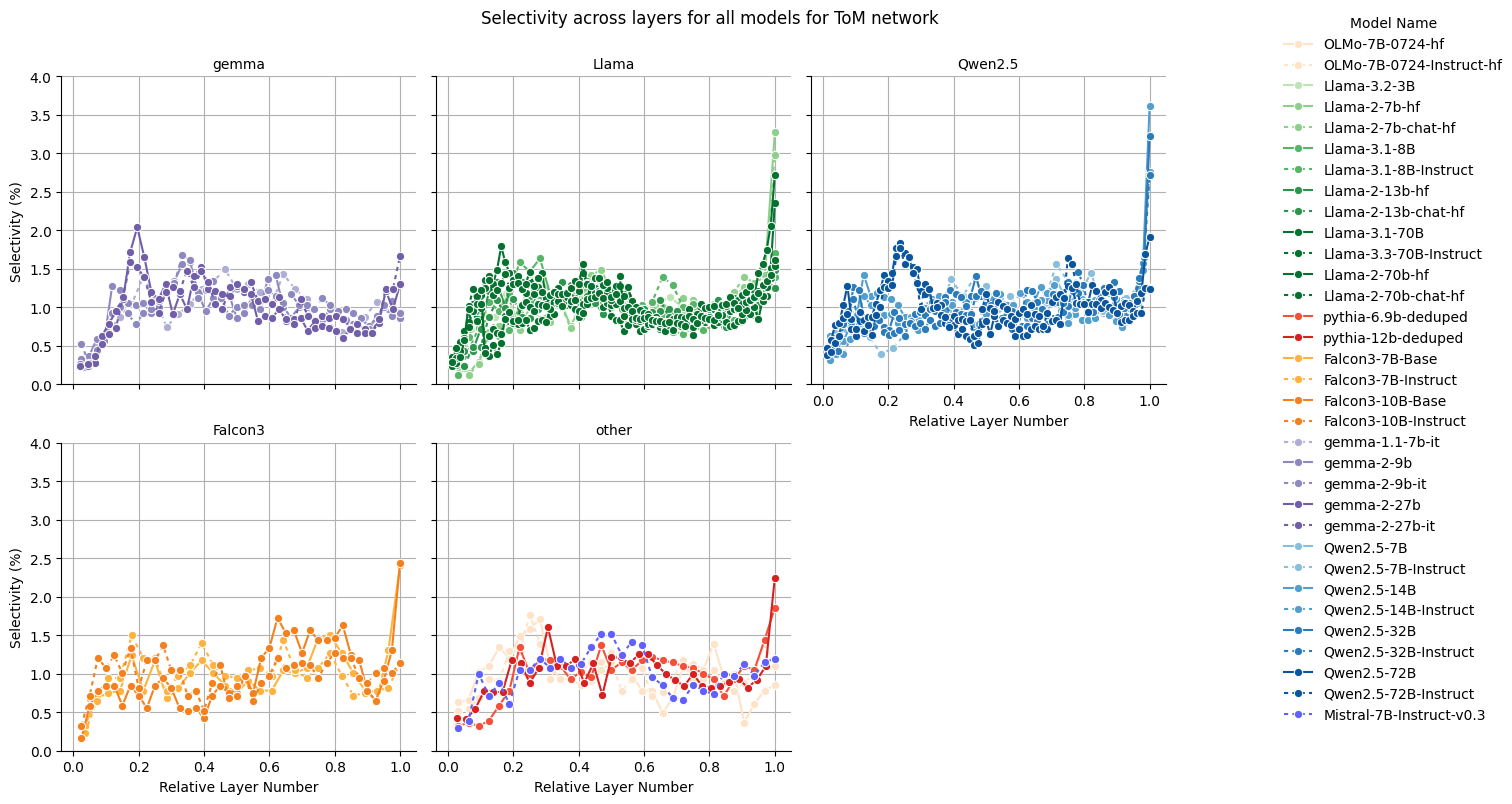

In [72]:
g = sns.FacetGrid(
    all_df_tom,
    col="family",
    hue="model_name",
    hue_order=list(MODEL_PAL.keys()),
    palette=MODEL_PAL,
    col_wrap=3,
    height=4,
    aspect=1,
    legend_out=True,
)

g.map_dataframe(
    sns.lineplot,
    x="relative_layer_num",
    y="selectivity",
    style="is_instruct",
    dashes={False: "", True: (2, 2)},
    markers=True,
    legend=False,
)

# axis labels
g.set_axis_labels("Relative Layer Number", "Selectivity (%)")

# facet titles
g.set_titles(col_template="{col_name}")

# y-limits and grid per axis
for ax in g.axes.flat:
    ax.set_ylim(0, 4)
    ax.grid(True)

# legend
g.add_legend(title="Model Name")
g._legend.set_bbox_to_anchor((0.89, 1))
g._legend.set_loc("upper left")

# global title
g.fig.suptitle(
    "Selectivity across layers for all models for ToM network",
    y=1.00,
)

g.tight_layout()
plt.show()


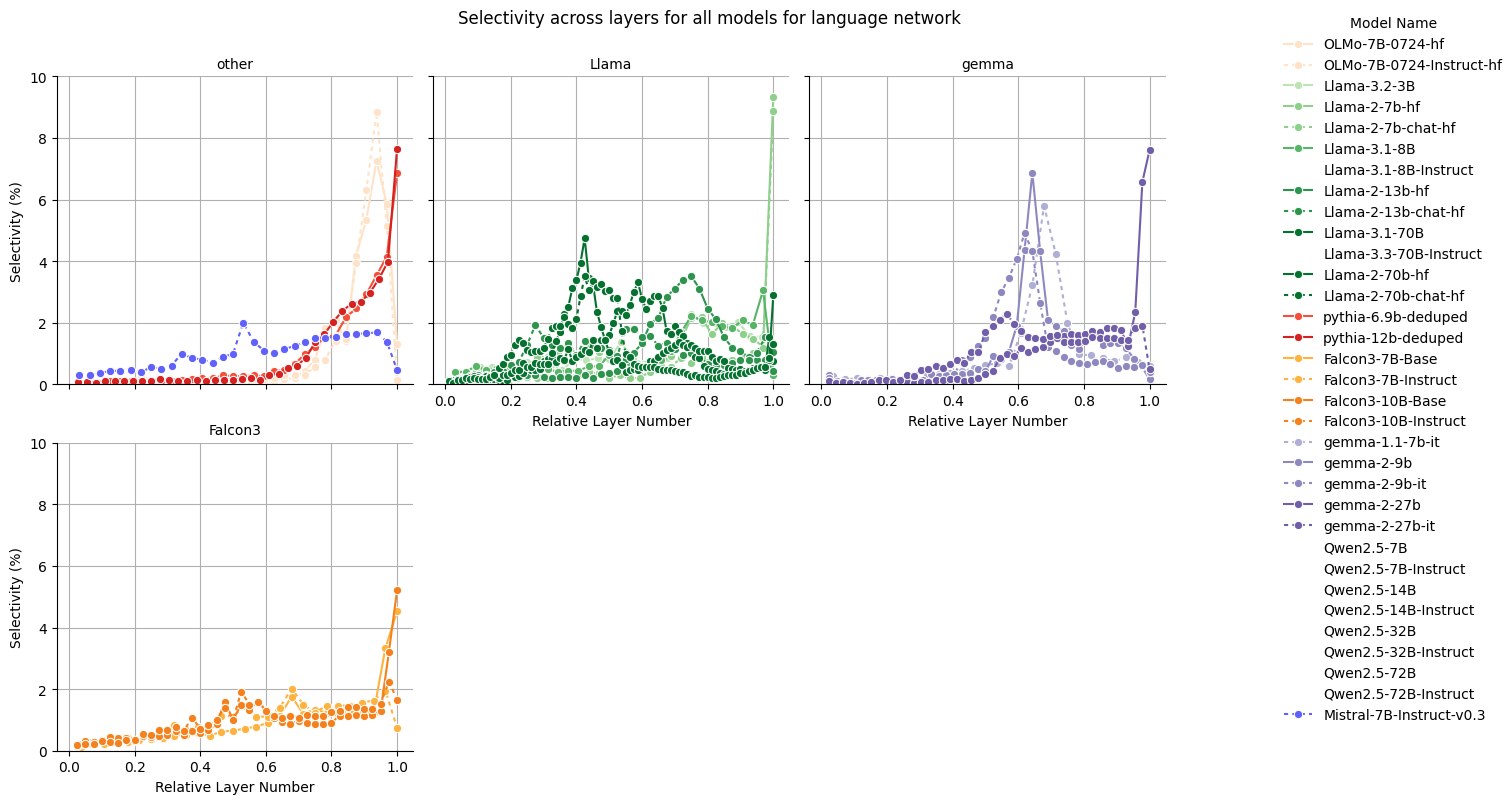

In [71]:
g_lang = sns.FacetGrid(
    all_df_lang,
    col="family",
    hue="model_name",
    hue_order=list(MODEL_PAL.keys()),
    palette=MODEL_PAL,
    col_wrap=3,
    height=4,
    aspect=1,
    legend_out=True,
)

g_lang.map_dataframe(
    sns.lineplot,
    x="relative_layer_num",
    y="selectivity",
    style="is_instruct",
    dashes={False: "", True: (2, 2)},
    markers=True,
    legend=False,
)

# axis labels
g_lang.set_axis_labels("Relative Layer Number", "Selectivity (%)")

# facet titles
g_lang.set_titles(col_template="{col_name}")

# y-limits and grid per axis
for ax in g_lang.axes.flat:
    ax.set_ylim(0, 10)
    ax.grid(True)

# legend
g_lang.add_legend(title="Model Name")
g_lang._legend.set_bbox_to_anchor((0.89, 1))
g_lang._legend.set_loc("upper left")

# global title
g_lang.fig.suptitle(
    "Selectivity across layers for all models for language network",
    y=1.00,
)

g_lang.tight_layout()
plt.show()


In [30]:
set(selectivities_data_tom.keys()) - set(selectivities_data_lang.keys())

{'Llama-3.1-8B-Instruct',
 'Llama-3.3-70B-Instruct',
 'Qwen2.5-14B',
 'Qwen2.5-14B-Instruct',
 'Qwen2.5-32B',
 'Qwen2.5-32B-Instruct',
 'Qwen2.5-72B',
 'Qwen2.5-72B-Instruct',
 'Qwen2.5-7B',
 'Qwen2.5-7B-Instruct'}

## Visualizing localizations with synthetic datasets

Below, we plot the proportion of most significant and least significant neurons identified with our different localization procedures (simple and conjunctive) on synthetic datasets.

In [2]:
analyses = [
    "tom|theory-of-mind",
    "tom|theory-of-mind-conjunctive",
    "tom|random",
    "tom|random-conjunctive" 
]

In [13]:
blues = sns.color_palette("Blues")
reds = sns.color_palette("Reds")
greens = sns.color_palette("Greens")
oranges = sns.color_palette("Oranges")
purples = sns.color_palette("Purples")
yellows = sns.color_palette("YlOrBr")
light_blues = sns.color_palette("light:b")

MODEL_SELECTED = {
    "Llama-3.1-8B": greens[2],
    "Llama-3.1-8B-Instruct": greens[2],
    "Llama-2-13b-hf": greens[3],
    "Llama-2-13b-chat-hf": greens[3],
    "Llama-3.1-70B": greens[4],
    "Llama-3.3-70B-Instruct": greens[4],
    
    "Falcon3-7B-Base": yellows[2],
    "Falcon3-7B-Instruct": yellows[2],
    "Falcon3-10B-Base": yellows[3],
    "Falcon3-10B-Instruct": yellows[3],

    "gemma-2-9b": purples[2],
    "gemma-2-9b-it": purples[2],
    "gemma-2-27b": purples[3],
    "gemma-2-27b-it": purples[3],

    "Qwen2.5-7B": blues[2],
    "Qwen2.5-7B-Instruct": blues[2],
    "Qwen2.5-32B": blues[3],
    "Qwen2.5-32B-Instruct": blues[3],
    "Qwen2.5-72B": blues[4],
    "Qwen2.5-72B-Instruct": blues[4]
}

In [40]:
CACHE_DIR = "../cache_tom_fb_synthetic"

In [41]:
file_list = os.listdir(f"{CACHE_DIR}")
print("all files ", len(file_list))
selectivities_data_tom = {}
selectivities_data_lang = {}
for path in file_list:
    # print("path ", path)
    if "pvalues" in path:
        continue
    if path == "plots":
        continue
    if "ipynb_checkpoints" in path:
        continue
    model_name = path.split("_network=")[0]
    network = "theory-of-mind" if "network=theory-of-mind" in path else "language"
    localization_suite = path.split("_suite=")[-1].split("_percentage=")[0]
    mask_type = path.split("_mask=")[-1].replace("_fdr.npy", "")
    # print("plotting results for model, network, localization suite, maks type:", model_name, network, localization_suite, mask_type)
    plot_data = {"selectivity": [], "layer_num": [], "model_name": []}  

    model_name = os.path.basename(model_name)
    num_layers = get_num_blocks(model_name)
    hidden_dim = get_hidden_dim(model_name)

    # print(f"Model: {model_name}")

    pooling = path.split("_pooling=")[-1].split("_pretrained=")[0]
    # model_loc_path = f"{model_name}_network={network}_pooling={pooling}_range=100-100_perc={percentage}_nunits=None_pretrained=True.npy"

    lang_mask_path = f"{CACHE_DIR}/{path}"
    if not os.path.exists(lang_mask_path):
        print(f"Path does not exist: {lang_mask_path}")
        continue

    lang_mask = np.load(lang_mask_path)

    for i in range(num_layers):
        layer_mask = lang_mask[i]

        value = 0 if len(layer_mask) == 0 else (layer_mask.sum() / hidden_dim) * 100
        plot_data["selectivity"].append(value)

        plot_data["layer_num"].append((i+1))
        plot_data["model_name"].append(model_name_map[model_name])

    plot_data["relative_layer_num"] = [ln / num_layers for ln in plot_data["layer_num"]]
    plot_data["localizer_suite"] = [localization_suite] * len(plot_data["relative_layer_num"])
    plot_data["mask_type"] = [mask_type] * len(plot_data["relative_layer_num"])
    if network == "theory-of-mind":
        # selectivities_data_tom[localization_suite] = {mask_type : {model_name: plot_data}}
        selectivities_data_tom \
            .setdefault(localization_suite, {}) \
            .setdefault(mask_type, {})[model_name] = plot_data
    else:
        selectivities_data_lang[model_name] = plot_data

    df = pd.DataFrame(plot_data)

all files  165


In [42]:
dfs_tom = []

for suite_name, data in selectivities_data_tom.items():
    for mask_type, dfs in data.items():
        for model_name, plot_data in dfs.items():
            df = pd.DataFrame(plot_data)
            df["model_name"] = model_name
            df["is_instruct"] = (
                "instruct" in model_name.lower()
                or "chat" in model_name.lower()
                or "-it" in model_name.lower()
            )
            df["family"] = model_name.split("-")[0]
            if any([model_name.split("-")[0] == n for n in ["OLMo", "pythia", "Mistral"]]):
                df["family"] = "other"
            dfs_tom.append(df)
            # print("model_name ", df.columns)

all_df_tom = pd.concat(dfs_tom, ignore_index=True)

In [43]:
all_df_tom_simple = all_df_tom[all_df_tom["mask_type"] == "theory-of-mind"]
all_df_tom_conjunctive = all_df_tom[all_df_tom["mask_type"] == "theory-of-mind-conjunctive"]
all_df_tom_random = all_df_tom[all_df_tom["mask_type"] == "random"]
all_df_tom_random_conjunctive = all_df_tom[all_df_tom["mask_type"] == "random-conjunctive"]

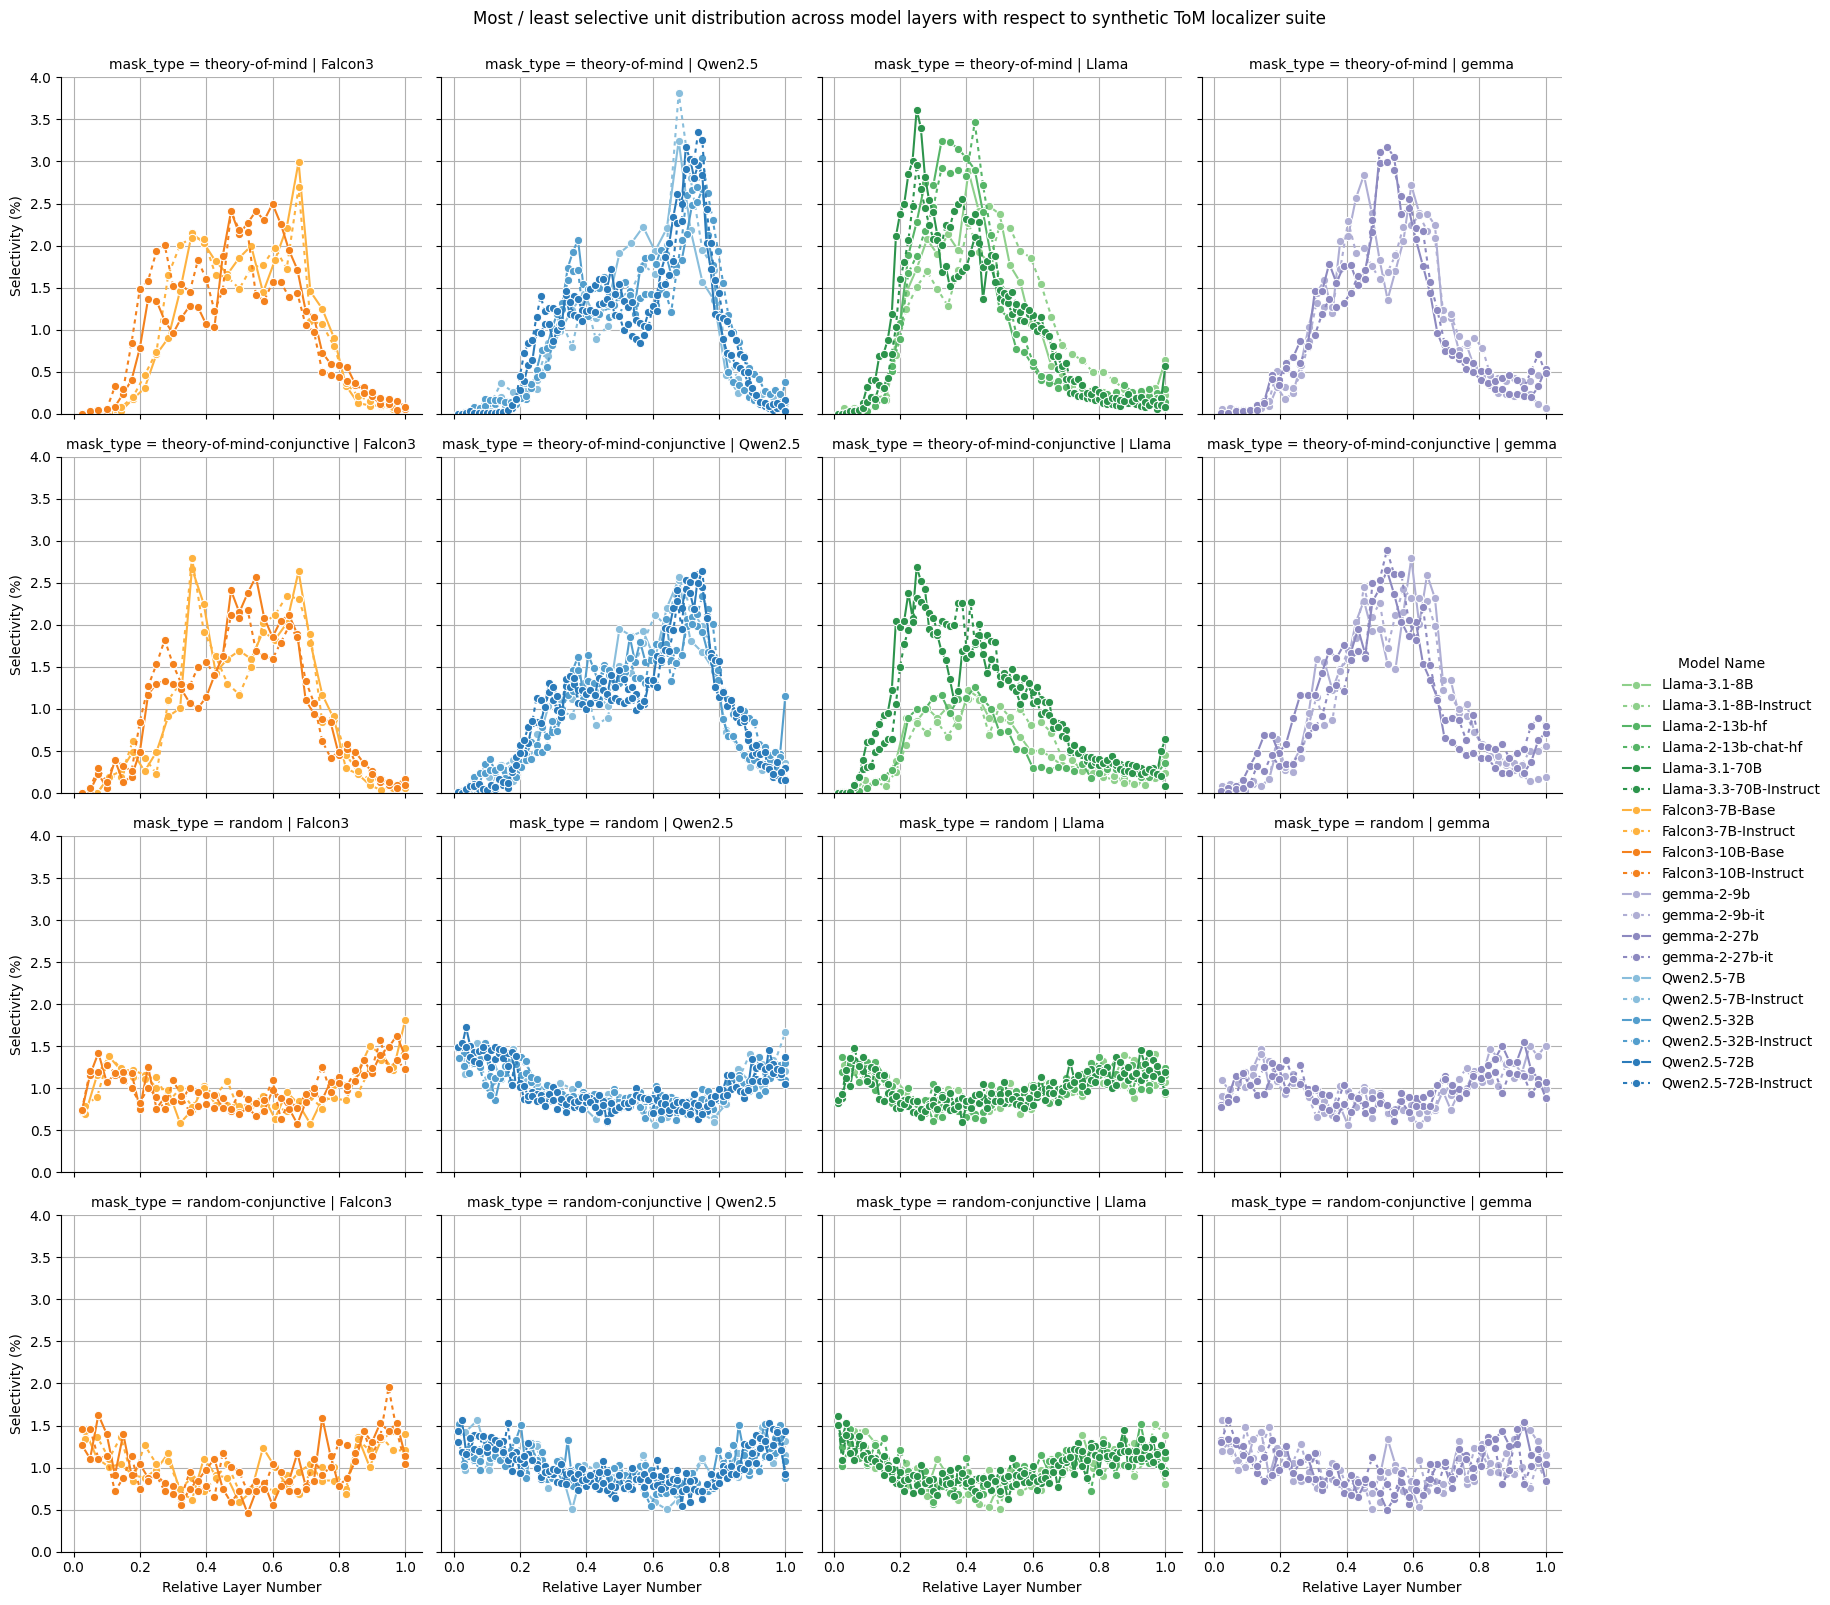

In [47]:
g_tom = sns.FacetGrid(
    all_df_tom,
    col="family",
    row="mask_type",
    hue="model_name",
    hue_order=list(MODEL_SELECTED.keys()),
    row_order=["theory-of-mind", "theory-of-mind-conjunctive", "random", "random-conjunctive"],
    palette=MODEL_SELECTED,
    # col_wrap=4,
    height=4,
    aspect=1,
    legend_out=True,
)

g_tom.map_dataframe(
    sns.lineplot,
    x="relative_layer_num",
    y="selectivity",
    style="is_instruct",
    dashes={False: "", True: (2, 2)},
    markers=True,
    legend=False,
    errorbar=None,
)

# axis labels
g_tom.set_axis_labels("Relative Layer Number", "Selectivity (%)")

# facet titles
g_tom.set_titles(col_template="{col_name}")

# y-limits and grid per axis
for ax in g_tom.axes.flat:
    ax.set_ylim(0, 4)
    ax.grid(True)

# legend
g_tom.add_legend(title="Model Name")
g_tom._legend.set_bbox_to_anchor((0.89, 0.6))
g_tom._legend.set_loc("upper left")

# global title
g_tom.fig.suptitle(
    "Most / least selective unit distribution across model layers with respect to synthetic ToM localizer suite",
    y=1.00,
)

g_tom.tight_layout()
# plt.savefig("suite=tom-synthetic_subnetwork-distribution.png")
plt.show()


### Localization under simple selection on original versions of the suites

In [48]:
CACHE_DIR = "../cache_original_stimuli"
file_list = os.listdir(f"{CACHE_DIR}")
print("all files ", len(file_list))
selectivities_data_tom = {}
selectivities_data_lang = {}
for path in file_list:
    # print("path ", path)
    if "pvalues" in path:
        continue
    if path == "plots":
        continue
    if "ipynb_checkpoints" in path:
        continue
    model_name = path.split("_network=")[0]
    network = "theory-of-mind" if "network=theory-of-mind" in path else "language"
    localization_suite = path.split("_suite=")[-1].split("_percentage=")[0]
    mask_type = path.split("_mask=")[-1].replace("_fdr.npy", "")
    # print("plotting results for model, network, localization suite, maks type:", model_name, network, localization_suite, mask_type)
    plot_data = {"selectivity": [], "layer_num": [], "model_name": []}  

    model_name = os.path.basename(model_name)
    num_layers = get_num_blocks(model_name)
    hidden_dim = get_hidden_dim(model_name)

    # print(f"Model: {model_name}")

    pooling = path.split("_pooling=")[-1].split("_pretrained=")[0]
    # model_loc_path = f"{model_name}_network={network}_pooling={pooling}_range=100-100_perc={percentage}_nunits=None_pretrained=True.npy"

    lang_mask_path = f"{CACHE_DIR}/{path}"
    if not os.path.exists(lang_mask_path):
        print(f"Path does not exist: {lang_mask_path}")
        continue

    lang_mask = np.load(lang_mask_path)

    for i in range(num_layers):
        layer_mask = lang_mask[i]

        value = 0 if len(layer_mask) == 0 else (layer_mask.sum() / hidden_dim) * 100
        plot_data["selectivity"].append(value)

        plot_data["layer_num"].append((i+1))
        plot_data["model_name"].append(model_name_map[model_name])

    plot_data["relative_layer_num"] = [ln / num_layers for ln in plot_data["layer_num"]]
    plot_data["localizer_suite"] = [localization_suite] * len(plot_data["relative_layer_num"])
    plot_data["mask_type"] = [mask_type] * len(plot_data["relative_layer_num"])
    if network == "theory-of-mind":
        # selectivities_data_tom[localization_suite] = {mask_type : {model_name: plot_data}}
        selectivities_data_tom \
            .setdefault(localization_suite, {}) \
            .setdefault(mask_type, {})[model_name] = plot_data
    else:
        selectivities_data_lang[model_name] = plot_data

    df = pd.DataFrame(plot_data)

all files  140


In [49]:
dfs_tom = []

for suite_name, data in selectivities_data_tom.items():
    for mask_type, dfs in data.items():
        for model_name, plot_data in dfs.items():
            df = pd.DataFrame(plot_data)
            df["model_name"] = model_name
            df["is_instruct"] = (
                "instruct" in model_name.lower()
                or "chat" in model_name.lower()
                or "-it" in model_name.lower()
            )
            df["family"] = model_name.split("-")[0]
            if any([model_name.split("-")[0] == n for n in ["OLMo", "pythia", "Mistral"]]):
                df["family"] = "other"
            dfs_tom.append(df)
            # print("model_name ", df.columns)

all_df_tom = pd.concat(dfs_tom, ignore_index=True)

In [38]:
all_df_tom_simple = all_df_tom[all_df_tom["mask_type"] == "theory-of-mind"]
all_df_tom_random = all_df_tom[all_df_tom["mask_type"] == "random"]

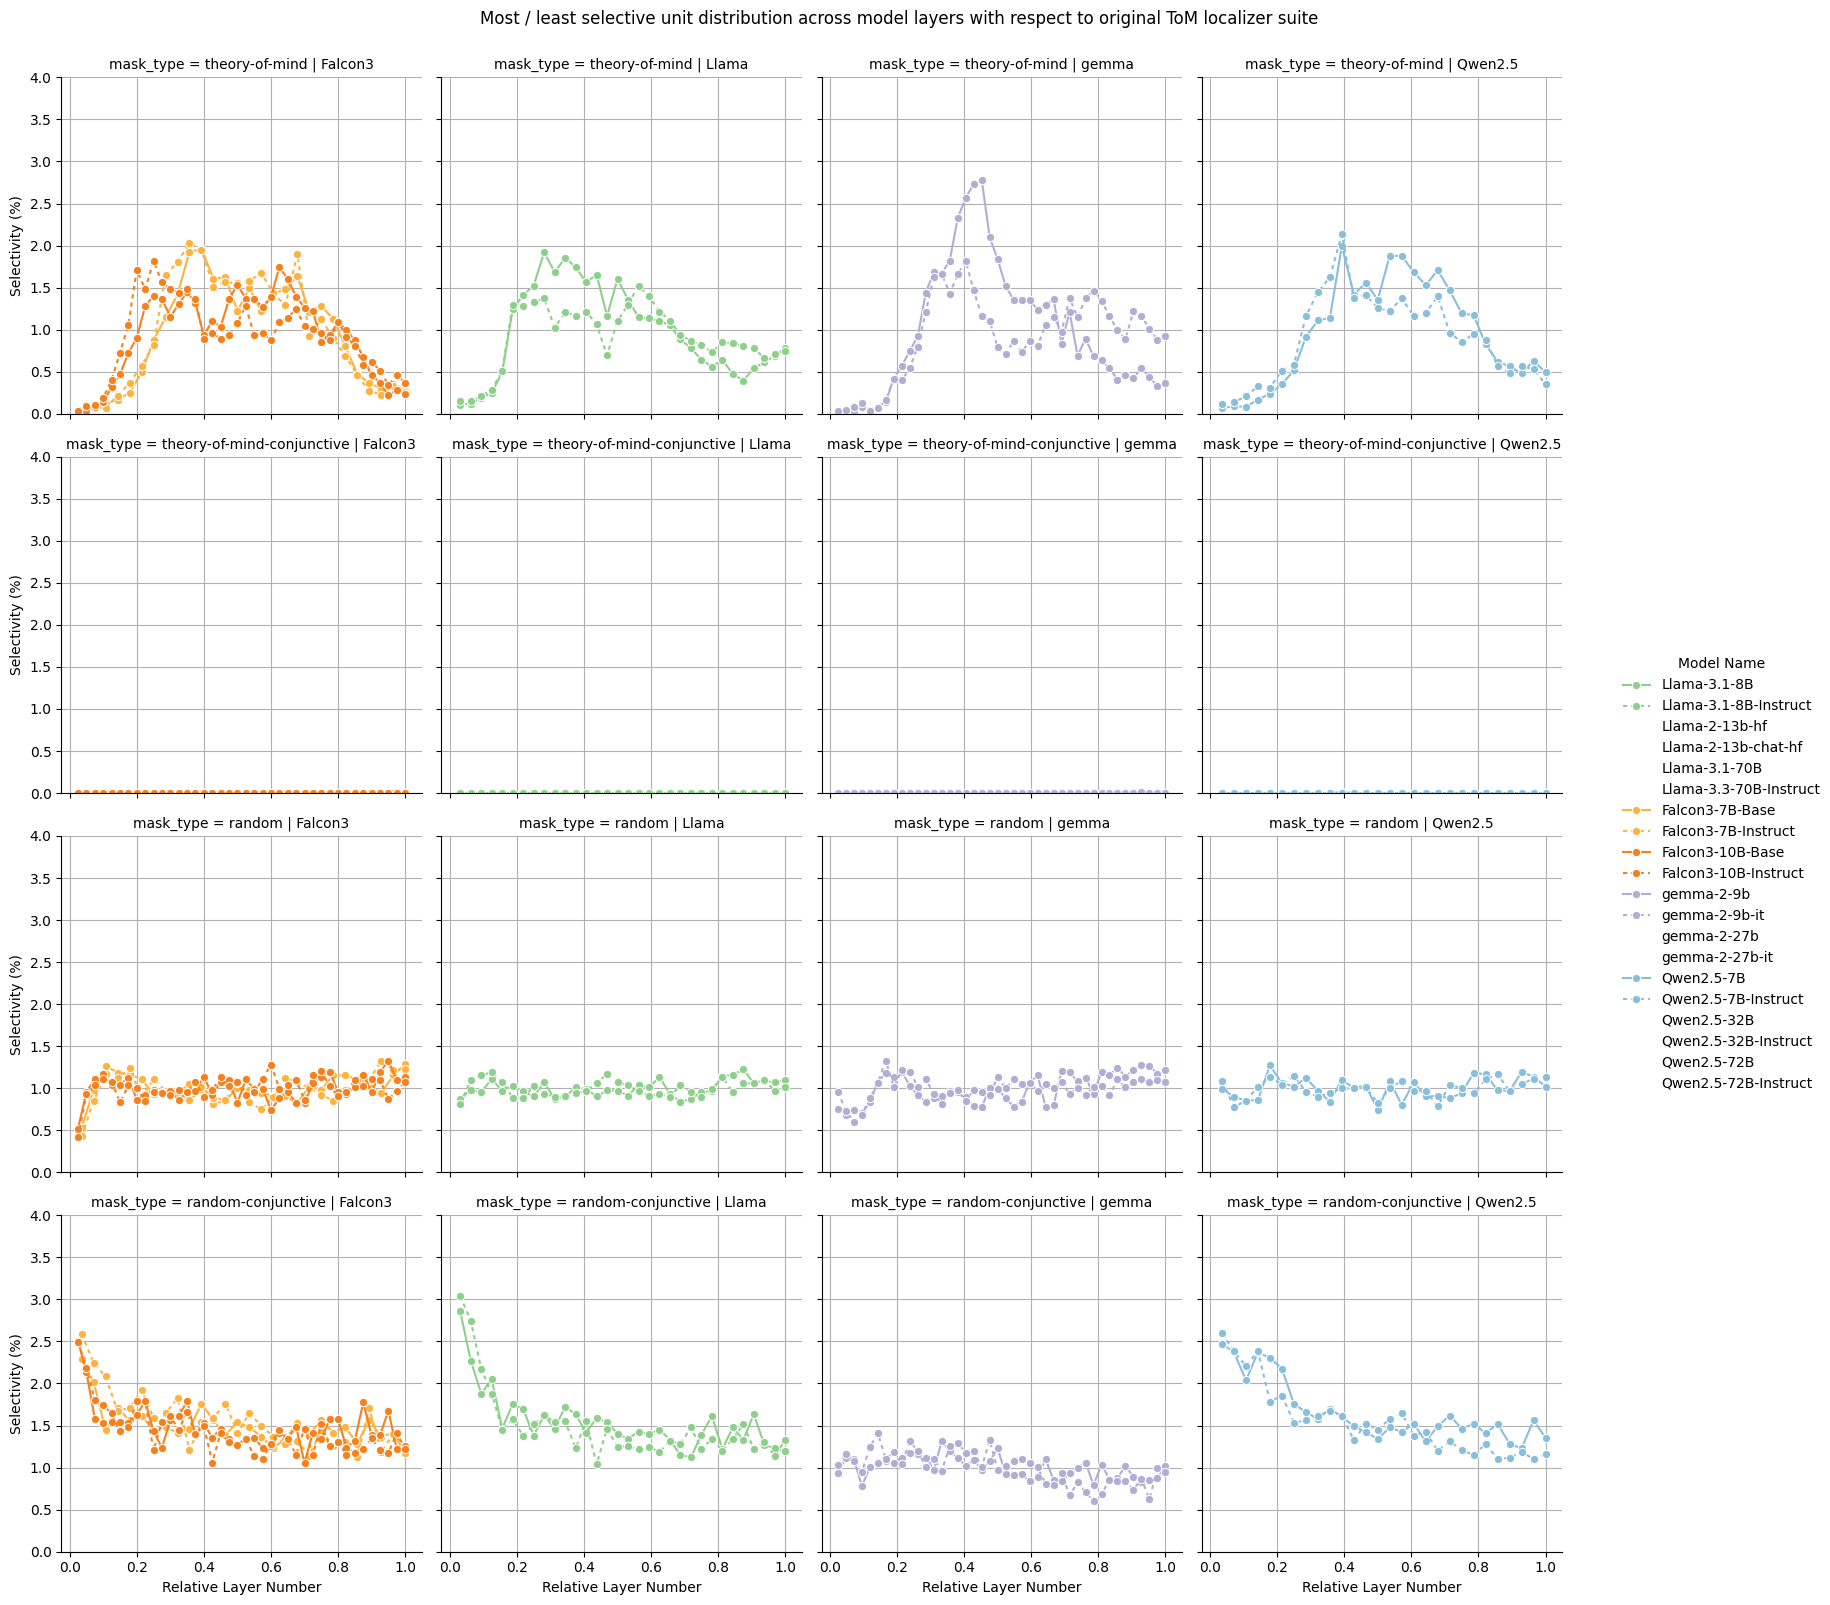

In [50]:
g_tom = sns.FacetGrid(
    all_df_tom,
    col="family",
    row="mask_type",
    hue="model_name",
    hue_order=list(MODEL_SELECTED.keys()),
    row_order=["theory-of-mind", "theory-of-mind-conjunctive", "random", "random-conjunctive"],
    palette=MODEL_SELECTED,
    # col_wrap=4,
    height=4,
    aspect=1,
    legend_out=True,
)

g_tom.map_dataframe(
    sns.lineplot,
    x="relative_layer_num",
    y="selectivity",
    style="is_instruct",
    dashes={False: "", True: (2, 2)},
    markers=True,
    legend=False,
    errorbar=None,
)

# axis labels
g_tom.set_axis_labels("Relative Layer Number", "Selectivity (%)")

# facet titles
g_tom.set_titles(col_template="{col_name}")

# y-limits and grid per axis
for ax in g_tom.axes.flat:
    ax.set_ylim(0, 4)
    ax.grid(True)

# legend
g_tom.add_legend(title="Model Name")
g_tom._legend.set_bbox_to_anchor((0.89, 0.6))
g_tom._legend.set_loc("upper left")

# global title
g_tom.fig.suptitle(
    "Most / least selective unit distribution across model layers with respect to original ToM localizer suite",
    y=1.00,
)

g_tom.tight_layout()
g_tom.savefig("suite=tom-original_subnetwork-distribution.png")
plt.show()
